In [85]:
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

In [86]:
TASK_TYPE = 0
TARGET_ACCURACY = 0.8
CLASS_INDEX = '2'
OMV_FEATURE_INDEX = [5, 6]

INITIAL_FPS = '15'
RESAMPLE_RATE = 2

SAFEGUARD_THRESHOLD = 0.01
SAFEGUARD_INDICATOR = -1
RP_AMOUNT = 4
RP_PERIOD = 4

SMOOTH_AMOUNT = 19
ARP_PERIOD = 36

In [87]:
# Plot
plot_directory = 'dataset/video_result'
power_profile_directory = 'dataset/FPS-Power.json'

In [88]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [89]:
colors = [
	'#e6194B',
	'#9A6324',
	'#911eb4',
	'#3cb44b',
	'#f032e6',
	'#4363d8',
]

In [90]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [91]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [92]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [93]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [94]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [95]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [96]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [97]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU", "Object Size"]

In [98]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [99]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

# Dataset

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [101]:
def transpose_array(arr):
	# Transpose the input array using zip and map it back to a list
	return [list(row) for row in zip(*arr)]

In [102]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [103]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):	
			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			# outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			# omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			# acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

# Train and Test

In [104]:
def estimate_best_fps_v1(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	for i in range(len(fpss)):
		if accuracy_vector[i] >= target_accuracy:
			return fpss[min(i + safeguard, len(fpss)-1)]

	return fpss[-1]

In [105]:
def estimate_best_fps_v2(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i

	return fpss[min(min_idx + safeguard, len(fpss) - 1)]

In [106]:
def estimate_best_fps_v3(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard, last_fps):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i
	
	corrected_min_idx = min_idx + safeguard
	if corrected_min_idx >= len(fpss) - 1:
		if last_fps == len(fpss) - 2:
			corrected_min_idx = len(fpss) - 1
		else:
			corrected_min_idx = len(fpss) - 2

	return fpss[corrected_min_idx]

In [107]:
def extract_metric_list(metric_list, fpss, feature='F1'):
	result_column = {}
	
	for fps in fpss: 
		result_column[fps] = [clip_metric['metric'][fps][feature] for clip_metric in metric_list]
	
	return result_column

In [108]:
def find_max_index(string_list):
	# Convert each element to integer
	int_list = [int(element) for element in string_list]
	
	# Find index of maximum integer value
	max_index, max_value = max(enumerate(int_list), key=lambda x: x[1])
	
	return max_value

def extract_cheapest_fps(accuracy_dict, fpss, threshold=0.75):
	max_fps = find_max_index(fpss)
	
	cheapest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = max_fps
		for fps in fpss:
			if accuracy_dict[fps][i] >= threshold and int(fps) < int(curr_fps):
				curr_fps = fps
		
		cheapest_fpss.append(int(curr_fps))
	
	return cheapest_fpss

In [109]:
def extract_nearest_fps(accuracy_dict, fpss, threshold=0.75):
	nearest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = fpss[0]
		for fps in fpss:
			if abs(accuracy_dict[fps][i] - threshold) < abs(accuracy_dict[curr_fps][i] - threshold):
				curr_fps = fps
		
		nearest_fpss.append(int(curr_fps))
	
	return nearest_fpss

In [110]:
def plot_multiple_lines(xs, yss, x_label, y_label, y_legends, title, fig_size, label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=fig_size)

	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], label=y_legends[i])

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [111]:
def plot_multiple_lines_horizontal(xs, yss, x_axis, y_axis, y_label_prefix, y_labels, title, label_size=28, font_size=32, legend_size=16, line_width=3):
	fig, ax1 = plt.subplots(figsize=(9, 6))
	
	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], marker='o', label=f'{y_label_prefix}{y_labels[i]}')

	ax1.set_xlabel(x_axis, fontsize=font_size)
	ax1.set_ylabel(y_axis, fontsize=font_size)
	ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [112]:
def generate_train_index_sets(data_length, rp_period, rp_amount):
	train_sets = []
	curr_index = 0
	while curr_index < data_length:
		train_sets.append(list(range(curr_index, curr_index + rp_amount)))
		curr_index += rp_period
	
	return train_sets

In [113]:
def transpose_2d_list(matrix):
	"""
	Transpose a 2D list (matrix).

	Args:
			matrix (list of lists): The 2D list to transpose.

	Returns:
			list of lists: The transposed 2D list.
	"""
	# Use zip with unpacking to transpose the matrix
	return [list(row) for row in zip(*matrix)]

In [114]:
def smooth_list(data, window_size=3):
    """
    Smooth a list of floats using a moving average.

    Parameters:
    - data: list of float, the input data to be smoothed.
    - window_size: int, the size of the moving window (must be odd).

    Returns:
    - list of float, the smoothed data.
    """
    if window_size < 1 or window_size % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    if len(data) < window_size:
        raise ValueError("Data list must be longer than the window size.")

    half_window = window_size // 2
    smoothed = []

    for i in range(len(data)):
        # Define the window range
        start = max(0, i - half_window)
        end = min(len(data), i + half_window + 1)
        # Compute the average of the window
        smoothed.append(sum(data[start:end]) / (end - start))

    return smoothed

In [115]:
def extract_elements_by_indices(lst, index_list):
    """
    Extract elements from a list based on the indices provided in another list.
    
    Parameters:
        lst (list): The list from which elements are to be extracted.
        index_list (list of int): The indices of the elements to extract.
    
    Returns:
        list: A list containing the elements at the specified indices.
    """
    return [lst[i] for i in index_list if i < len(lst)]


## Algorithms

In [116]:
def decide_safeguard_weight(train_mse_list, threshold=SAFEGUARD_THRESHOLD):
	return [1 if mse >= threshold else 0 for mse in train_mse_list]

In [117]:
def decide_best_fps(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard_weight):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i

	corrected_min_idx = min(min_idx + safeguard_weight[i], len(fpss) - 1)
	return fpss[corrected_min_idx]

In [118]:
def decide_adaptive_train_index(period_video_name):
	x_all = dataset[period_video_name]['30']['x_all']
	con_list = transpose_2d_list(x_all)[0]
	iou_list = transpose_2d_list(x_all)[1]
	
	test_length = len(con_list)
	con_omv_corr_list = []
	for i in range(RP_AMOUNT, test_length):
		correlation_matrix = np.corrcoef(con_list[i-RP_AMOUNT : i], iou_list[i-RP_AMOUNT : i])
		correlation = correlation_matrix[0, 1]
		con_omv_corr_list.append(correlation)
	
	smooth_con_omv_corr_list = smooth_list(con_omv_corr_list, SMOOTH_AMOUNT)
	# time = list(range(RP_AMOUNT, test_length))
	# plot_multiple_lines(time, [smooth_con_omv_corr_list], 'Time', 'FPS', ['Confidence OMV Correlation'], '', (36, 9))
	assert(len(smooth_con_omv_corr_list) == len(con_omv_corr_list))

	filtered_corr_list = [x for x in smooth_con_omv_corr_list if not math.isnan(x)]
	corr_average = np.median(np.array(filtered_corr_list))
	corr_std = np.std(np.array(filtered_corr_list))

	ceil_bound = corr_average + 1.1 * corr_std
	floor_bound = corr_average - 1.1 * corr_std

	optimum_timestamp = [(ts + RP_AMOUNT) for ts in range(len(smooth_con_omv_corr_list)) if (not math.isnan(smooth_con_omv_corr_list[ts])) and (smooth_con_omv_corr_list[ts] < floor_bound or smooth_con_omv_corr_list[ts] > ceil_bound)]
	
	selected_timestamp = []
	idx = 4 * RP_AMOUNT
	while idx < test_length - 3 * RP_AMOUNT:
		if idx in optimum_timestamp:
			selected_timestamp.append(idx)
			idx += ARP_PERIOD
		idx += 1
	
	train_index_list_adaptive = [list(range(ts, ts+RP_AMOUNT)) for ts in selected_timestamp]
	return train_index_list_adaptive

In [119]:
def find_local_extrema(lst):
    """
    Find all indices of local minima and maxima in a list while ignoring NaN values.

    Parameters:
        lst (list of float): The input list, which may contain NaN values.

    Returns:
        dict: A dictionary with keys 'minima' and 'maxima' containing the indices of local minima and maxima.
    """
    extrema = []
    
    for i in range(1, len(lst) - 1):
        if math.isnan(lst[i-1]) or math.isnan(lst[i]) or math.isnan(lst[i+1]):
            continue  # Skip NaN values and their neighbors

        # Local minimum
        if lst[i] < lst[i-1] and lst[i] < lst[i+1]:
            extrema.append(i)

        # Local maximum
        elif lst[i] > lst[i-1] and lst[i] > lst[i+1]:
            extrema.append(i)
    
    return extrema

In [120]:
def end_to_end_pipeline(period_video_name, train_index_list, sg_indicator=SAFEGUARD_INDICATOR):
	# Test
	test_length = len(dataset[period_video_name]['30']['x_all'])

	accuracy_result = load_json_file(os.path.join(plot_directory, period_video_name + "_Accuracy_Result.json"))
	accuracy = extract_metric_list(accuracy_result[CLASS_INDEX], fpss)
	nearest_fps_list = extract_nearest_fps(accuracy, fpss, TARGET_ACCURACY)

	selected_fps_list_for_accuracy = []
	selected_fps_list_for_power = []
	last_fps = INITIAL_FPS
	train_index_list_idx = 0
	adaptive_safeguard_weight = None
	uniform_safeguard_weight = [SAFEGUARD_INDICATOR for fps in fpss]
	for i in range(test_length):
		if train_index_list_idx < len(train_index_list) and i == train_index_list[train_index_list_idx][0]:
			# Train
			prediction_models = {}
			for fps in fpss:
				prediction_models[fps] = LinearRegression()

			train_mse_list = []
			for fps in fpss:
				x_all = dataset[period_video_name][fps]['x_all']
				y_all = dataset[period_video_name][fps]['y_all']

				train_start_idx = train_index_list[train_index_list_idx][0]
				train_end_idx = train_index_list[train_index_list_idx][-1]

				x_train = x_all[train_start_idx : train_end_idx]
				y_train = y_all[train_start_idx : train_end_idx]
						
				prediction_models[fps].fit(x_train, y_train)

				y_train_pred = prediction_models[fps].predict(x_train)
				train_mse = root_mean_squared_error(y_train, y_train_pred)
				train_mse_list.append(train_mse)
			
			adaptive_safeguard_weight = decide_safeguard_weight(train_mse_list)

		if train_index_list_idx < len(train_index_list) and i in train_index_list[train_index_list_idx]:
			ground_truth_fps = str(nearest_fps_list[i])
			selected_fps_list_for_accuracy.append(ground_truth_fps)
			selected_fps_list_for_power.append(fpss[-1])
			last_fps = ground_truth_fps
			
			if i == train_index_list[train_index_list_idx][-1]:
				train_index_list_idx += 1
			
			continue

		if i % RESAMPLE_RATE != 0:
			selected_fps_list_for_accuracy.append(last_fps)
			selected_fps_list_for_power.append(last_fps)
			continue

		clip_omv_of_fps = dataset[period_video_name][last_fps]['x_all'][i]

		if sg_indicator == -1:
			suggested_fps = decide_best_fps(prediction_models, clip_omv_of_fps, fpss, TARGET_ACCURACY, adaptive_safeguard_weight)
		else:
			suggested_fps = decide_best_fps(prediction_models, clip_omv_of_fps, fpss, TARGET_ACCURACY, uniform_safeguard_weight)

		last_fps = suggested_fps
		selected_fps_list_for_accuracy.append(last_fps)
		selected_fps_list_for_power.append(last_fps)

	selected_fps_list_for_accuracy = [int(x) for x in selected_fps_list_for_accuracy]
	selected_fps_list_for_power = [int(x) for x in selected_fps_list_for_power]

	selected_accuracy_list = []
	for i in range(test_length):
		selected_throughput = str(selected_fps_list_for_accuracy[i])
		selected_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][selected_throughput]['F1']
		selected_accuracy_list.append(selected_accuracy)
	
	nearest_accuracy_list = []
	for i in range(test_length):
		nearest_throughput = str(nearest_fps_list[i])
		nearest_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][nearest_throughput]['F1']
		nearest_accuracy_list.append(nearest_accuracy)

	power_profile = load_json_file(os.path.join(power_profile_directory))
	max_power = power_profile[str(max([int(k) for k in list(power_profile.keys())]))]

	selected_power_list = []
	for st in selected_fps_list_for_power:
		if str(st) in power_profile:
			selected_power_list.append(power_profile[str(st)])
		else:
			selected_power_list.append(max_power)

	nearest_power_list = []
	for nt in nearest_fps_list:
		if str(nt) in power_profile:
			nearest_power_list.append(power_profile[str(nt)])
		else:
			nearest_power_list.append(max_power)
	
	avg_selected_accuracy = float(np.mean(np.array(selected_accuracy_list)))
	avg_nearest_accuracy = float(np.mean(np.array(nearest_accuracy_list)))
	avg_selected_power = float(np.mean(np.array(selected_power_list)))
	avg_nearest_power = float(np.mean(np.array(nearest_power_list)))

	# print(f'Selected F1 Accuracy: {round(avg_selected_accuracy, 3)}')
	# print(f'Nearest F1 Accuracy: {round(avg_nearest_accuracy, 3)}')
	# print(f'Selected Power: {round(avg_selected_power, 3)}')
	# print(f'Nearest Power: {round(avg_nearest_power, 3)}')

	time = range(test_length)
	# plot_multiple_lines(time, [selected_fps_list_for_power, nearest_fps_list], 'Time', 'FPS', ['Selected', 'Optimal'], '', (24, 6))
	# plot_multiple_lines(time, [selected_accuracy_list, nearest_accuracy_list], 'Time', 'Accuracy', ['Selected Accuracy', 'Nearest Accuracy'], '', (36, 6))
	# plot_multiple_lines(time, [selected_power_list, nearest_power_list], 'Time', 'Power', ['Selected Power', 'Nearest Power'], '', (36, 6))

	return avg_selected_accuracy, avg_nearest_accuracy, avg_selected_power, avg_nearest_power

# Performing Evaluation 

In [121]:
overall_result = {}
overall_result[TARGET_ACCURACY] = {}
overall_result[TARGET_ACCURACY][TASK_TYPE] = {}

for period_video_name in plot_video_names:
	# print(period_video_name)

	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name] = {}
	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['accuracy'] = {}
	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['power'] = {}

	# Non Re-profiling
	train_index_list_non = [list(range(RP_AMOUNT))]
	non_accuracy, offline_accuracy, non_power, offline_power = end_to_end_pipeline(period_video_name, train_index_list_non)

	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['accuracy']["non"] = non_accuracy
	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['accuracy']["offline"] = offline_accuracy
	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['power']["non"] = non_power
	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['power']["offline"] = offline_power

	# Regular Re-profiling
	test_length = len(dataset[period_video_name]['30']['x_all'])
	train_index_list_regular = generate_train_index_sets(test_length, RP_PERIOD, RP_AMOUNT)
	regular_accuracy, _, regular_power, _ = end_to_end_pipeline(period_video_name, train_index_list_regular)

	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['accuracy']["regular"] = regular_accuracy
	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['power']["regular"] = regular_power

	# Adaptive Re-profiling
	train_index_list_adaptive = decide_adaptive_train_index(period_video_name)
	train_index_list_adaptive.insert(0, list(range(RP_AMOUNT)))
	adaptive_accuracy, _, adaptive_power, _ = end_to_end_pipeline(period_video_name, train_index_list_adaptive)

	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['accuracy']["adaptive"] = adaptive_accuracy
	overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['power']["adaptive"] = adaptive_power

	# print("")

/Users/jiaxili/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/function_base.py:2829: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/Users/jiaxili/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/function_base.py:2829: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/Users/jiaxili/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/function_base.py:2829: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/Users/jiaxili/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/function_base.py:2829: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]


In [122]:
def plot_bar_chart(values, categories, subcategories, title, x_label, y_label, y_range, label_size=24, tick_size=16, legend_size=12):
	# Organize data into groups
	data = {}
	for i in range(len(categories)):
		data[categories[i]] = values[i]

	# Plot settings
	bar_width = 0.25
	x = np.arange(len(categories))  # Group positions

	fig, ax = plt.subplots()

	# Plot each subgroup
	for i, subcategory in enumerate(subcategories):
		values = [data[cat][i] for cat in categories]
		ax.bar(x + i * bar_width, values, bar_width, label=f'{subcategory}', color=colors[i])

	# Labeling and formatting
	ax.set_xlabel(x_label, fontsize=label_size)
	ax.set_ylabel(y_label, fontsize=label_size)
	ax.set_title(title, fontsize=label_size)
	ax.set_xticks(x + bar_width)
	ax.set_xticklabels(categories, fontsize=tick_size)
	plt.tick_params(axis='y', labelsize=tick_size)
	ax.legend(fontsize=legend_size)

	ax.set_ylim(y_range[0], y_range[1])

	plt.tight_layout()
	plt.show()

In [123]:
def plot_bar_chart_with_line(values, categories, subcategories, hline_value, title, x_label, y_label, y_range, label_size=24, tick_size=16, legend_size=12):
	# Organize data into groups
	data = {}
	for i in range(len(categories)):
		data[categories[i]] = values[i]

	# Plot settings
	bar_width = 0.25
	x = np.arange(len(categories))  # Group positions

	fig, ax = plt.subplots()

	# Plot each subgroup
	for i, subcategory in enumerate(subcategories):
		values = [data[cat][i] for cat in categories]
		ax.bar(x + i * bar_width, values, bar_width, label=f'{subcategory}', color=colors[i])
	
	ax.axhline(y=hline_value, color='red')

	# Labeling and formatting
	ax.set_xlabel(x_label, fontsize=label_size)
	ax.set_ylabel(y_label, fontsize=label_size)
	ax.set_title(title, fontsize=label_size)
	ax.set_xticks(x + bar_width)
	ax.set_xticklabels(categories, fontsize=tick_size)
	plt.tick_params(axis='y', labelsize=tick_size)
	ax.legend(fontsize=legend_size)

	ax.set_ylim(y_range[0], y_range[1])

	plt.tight_layout()
	plt.show()

In [124]:
accuracy_yss = []
power_yss = []
for i in range(len(plot_video_names)):
	period_video_name = plot_video_names[i]
	video_accuracy = overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['accuracy']
	video_power = overall_result[TARGET_ACCURACY][TASK_TYPE][period_video_name]['power']
	
	accuracy_ys = [video_accuracy['non'], video_accuracy['regular'], video_accuracy['adaptive']]
	power_ys = [video_power['non'], video_power['regular'], video_power['adaptive']]

	print(i, period_video_name, accuracy_ys, power_ys)

	accuracy_yss.append(accuracy_ys)
	power_yss.append(power_ys)

0 1 [0.8279620101959783, 0.8251347486144689, 0.7413715234351019] [7.127770232478458, 11.447405954636075, 5.117412150879814]
1 10 [0.8205465434305959, 0.8380077804547784, 0.832294003774952] [6.59969795542128, 11.447405954636075, 6.484799599952709]
2 2 [0.7400134536527945, 0.7802411037349186, 0.7694273720606557] [5.07645124693976, 11.447405954636078, 5.27436403237492]
3 3 [0.7752339461630824, 0.809578859949814, 0.7859766123709384] [5.270371094432623, 11.447405954636075, 5.699408739355766]
4 4 [0.9346701139971215, 0.8053368690669238, 0.819005257997414] [4.830120734891439, 11.447405954636078, 4.905823291109656]
5 5 [0.7663165404715405, 0.8139376477492913, 0.8051151684410275] [5.174096687334741, 11.447405954636075, 5.615720841247214]
6 6 [0.9666181614397101, 0.8084655578664052, 0.8836929700944967] [9.32289471531443, 11.447405954636075, 7.11429430641421]
7 7 [0.8034018892796125, 0.8099056749791236, 0.8164704415831429] [4.042252316700589, 11.447405954636078, 4.7365484431732225]
8 8 [0.8532218

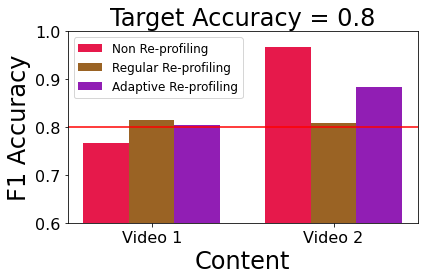

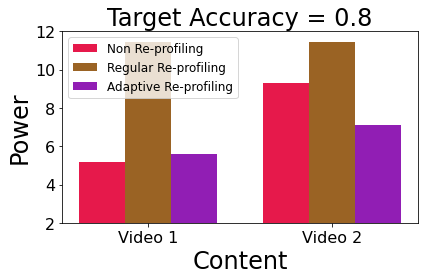

In [126]:
SELECTED_VIDEO_INDEX = [5, 6]

accuracy_yss_plot = extract_elements_by_indices(accuracy_yss, SELECTED_VIDEO_INDEX)
power_yss_plot = extract_elements_by_indices(power_yss, SELECTED_VIDEO_INDEX)

plot_bar_chart_with_line(accuracy_yss_plot, ['Video 1', 'Video 2'], ['Non Re-profiling', 'Regular Re-profiling', 'Adaptive Re-profiling'], TARGET_ACCURACY, f'Target Accuracy = {TARGET_ACCURACY}', 'Content', 'F1 Accuracy', (TARGET_ACCURACY-0.2, 1))
plot_bar_chart(power_yss_plot, ['Video 1', 'Video 2'], ['Non Re-profiling', 'Regular Re-profiling', 'Adaptive Re-profiling'], f'Target Accuracy = {TARGET_ACCURACY}', 'Content', 'Power', (2, 12))